# Task 1 — Data Cleaning & Exploration: Titanic Dataset

Dataset: [Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic/data) (Kaggle).
891 passenger records, 12 columns. Mirror pulled from a GitHub-hosted copy of the same Kaggle file
(`datasciencedojo/datasets/titanic.csv`) since this environment cannot hit kaggle.com directly.

Goals: clean missing values, drop duplicates, flag outliers, compute basic stats, visualize the shape of the data.
No modeling here — that's Task 3.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/titanic_raw.csv")
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Initial inspection

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 2. Missing values

Raw counts and percentages per column.

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report.missing_count > 0].sort_values("missing_pct", ascending=False)
missing_report

,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


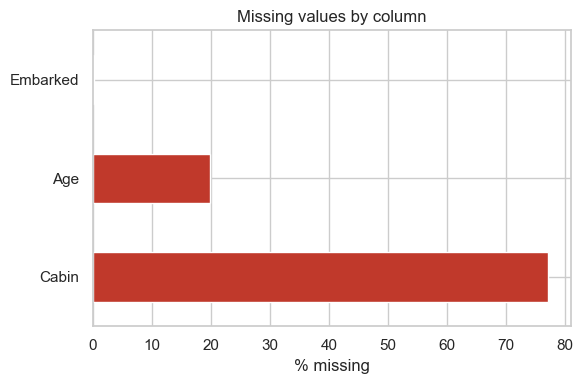

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
missing_report["missing_pct"].plot(kind="barh", ax=ax, color="#c0392b")
ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
plt.tight_layout()
plt.savefig("../images/missing_values.png", dpi=120)
plt.show()

**Findings:**
- `Cabin` is missing ~77% — too sparse to impute meaningfully. Converted to a binary `HasCabin` flag instead of dropping the column outright (cabin presence itself correlates with class/fare and is informative).
- `Age` is missing ~20% — imputed with the median `Age` within each `Pclass`/`Sex` group, since age distributions differ meaningfully across those groups (better than a single global median).
- `Embarked` is missing 2 rows — imputed with the mode (`S`), the dominant port by a wide margin.

In [9]:
# HasCabin flag before dropping Cabin
df["HasCabin"] = df["Cabin"].notna().astype(int)

# Age: median by Pclass + Sex
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(lambda s: s.fillna(s.median()))

# Embarked: mode fill
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin (too sparse to use directly) now that HasCabin captures the signal
df = df.drop(columns=["Cabin"])

print("Remaining nulls:\n", df.isnull().sum().sum())

Remaining nulls:
 0


## 3. Duplicates

In [10]:
dupe_count_all = df.duplicated().sum()
dupe_count_id = df.duplicated(subset=["PassengerId"]).sum()
print(f"Fully duplicated rows: {dupe_count_all}")
print(f"Duplicate PassengerId values: {dupe_count_id}")

Fully duplicated rows: 0
Duplicate PassengerId values: 0


**Finding:** no exact duplicate rows and no repeated `PassengerId` values. Nothing to drop here —
worth stating plainly rather than manufacturing a fix for a problem that isn't there.

## 4. Outliers

IQR method on the two continuous numeric columns that matter: `Age` and `Fare`.

In [11]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ["Age", "Fare"]:
    low, high = iqr_bounds(df[col])
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: bounds=({low:.2f}, {high:.2f}), outliers={n_out} ({n_out/len(df)*100:.1f}%)")

Age: bounds=(-0.25, 57.75), outliers=33 (3.7%)
Fare: bounds=(-26.72, 65.63), outliers=116 (13.0%)


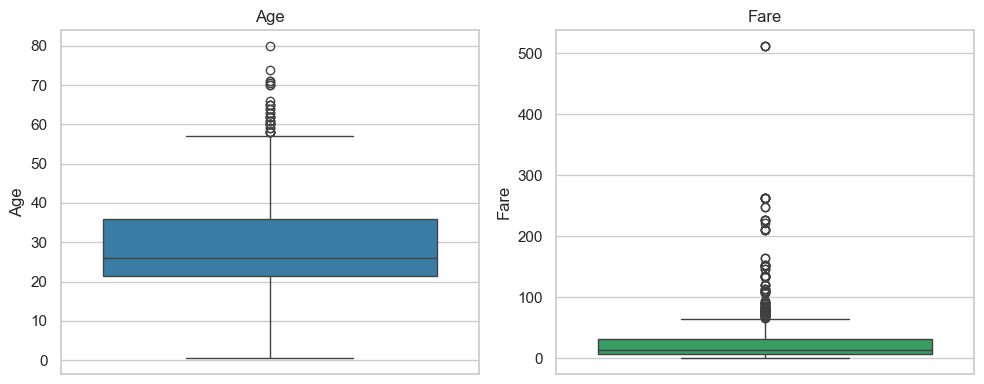

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df["Age"], ax=axes[0], color="#2980b9")
axes[0].set_title("Age")
sns.boxplot(y=df["Fare"], ax=axes[1], color="#27ae60")
axes[1].set_title("Fare")
plt.tight_layout()
plt.savefig("../images/outliers_boxplot.png", dpi=120)
plt.show()

**Decision:** `Fare` has a real, heavy right tail (~13% flagged by IQR) driven by first-class
passengers who paid a lot — that's a genuine signal, not noise, so these rows are kept and only flagged
in a new `FareOutlier` column rather than removed or capped. `Age` has a much smaller outlier share and
no implausible values (no negative ages, no ages over ~80), so it's left untouched.

In [14]:
low, high = iqr_bounds(df["Fare"])
df["FareOutlier"] = ((df["Fare"] < low) | (df["Fare"] > high)).astype(int)
df["FareOutlier"].value_counts()

FareOutlier
0    775
1    116
Name: count, dtype: int64

## 5. Basic statistics

In [15]:
df[["Age", "Fare", "SibSp", "Parch"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,891.0,29.112424,13.304424,0.42,21.5000,26.0000,36.0,80.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000


In [16]:
print("Survival rate overall: {:.1f}%".format(df["Survived"].mean() * 100))
print("\nSurvival rate by sex:")
print((df.groupby("Sex")["Survived"].mean() * 100).round(1))
print("\nSurvival rate by class:")
print((df.groupby("Pclass")["Survived"].mean() * 100).round(1))

Survival rate overall: 38.4%

Survival rate by sex:
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64

Survival rate by class:
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


## 6. Visualizations

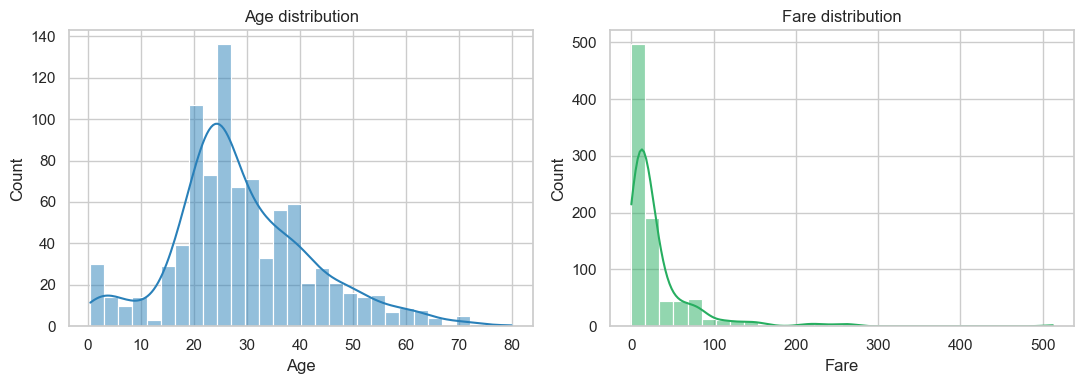

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["Age"], bins=30, kde=True, ax=axes[0], color="#2980b9")
axes[0].set_title("Age distribution")
sns.histplot(df["Fare"], bins=30, kde=True, ax=axes[1], color="#27ae60")
axes[1].set_title("Fare distribution")
plt.tight_layout()
plt.savefig("../images/distributions.png", dpi=120)
plt.show()

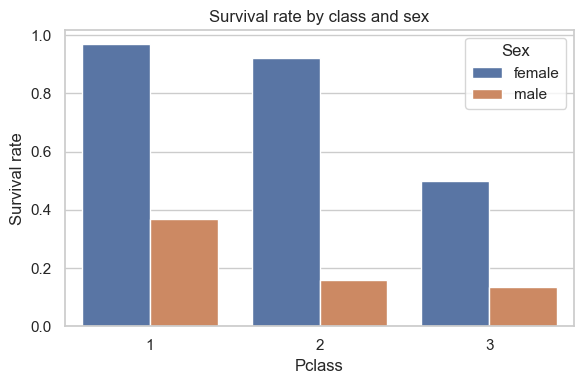

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex", ax=ax, errorbar=None)
ax.set_title("Survival rate by class and sex")
ax.set_ylabel("Survival rate")
plt.tight_layout()
plt.savefig("../images/survival_by_class_sex.png", dpi=120)
plt.show()

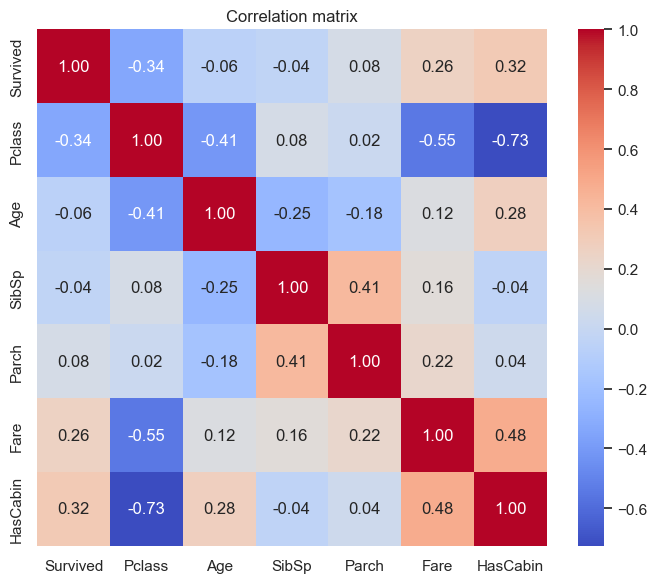

In [19]:
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "HasCabin"]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=120)
plt.show()

## 7. Honest Take

- Cleaning was mostly straightforward — this dataset's rough edges (`Age`, `Cabin`, `Embarked`) are well
  documented and don't need clever tricks, just defensible imputation choices.
- No duplicates existed; that check came back clean rather than manufacturing a finding.
- The interesting signal in `Fare`'s outliers is class-driven, so flagging beats stripping it out —
  removing it would throw away exactly the variance that matters for later survival analysis.
- `Sex` and `Pclass` are already visibly the strongest predictors of survival before any modeling —
  worth carrying that expectation into Task 3.
- Cleaned dataset saved as `titanic_cleaned.csv` for reuse in Tasks 2–4.

In [22]:
from pathlib import Path

Path("../output").mkdir(parents=True, exist_ok=True)

df.to_csv("../output/titanic_cleaned.csv", index=False)
df.shape

(891, 13)